In [ ]:
!pip install pandas numpy matplotlib seaborn wordcloud textblob nltk textstat spacy
!python -m spacy download en_core_web_sm

In [ ]:
!pip install pandas nltk emoji pyspellchecker scikit-learn tqdm
!python -m spacy download en_core_web_sm

In [ ]:
pip install wordcloud

In [ ]:
pip install textblob

In [ ]:
pip install textstat

In [ ]:
pip install spacy

In [ ]:
!python -m spacy download en_core_web_sm

In [ ]:
import sys
print(sys.executable)

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])

In [ ]:
pip install emoji

In [ ]:
!pip uninstall spellchecker
!pip install pyspellchecker

In [9]:
!pip install -U sentence-transformers


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [16]:
!pip install pandas numpy scikit-learn tensorflow transformers textblob nltk tqdm matplotlib seaborn
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import pandas as pd

df = pd.read_csv('fake reviews dataset.csv')

# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n")

# Check for duplicates
print("Duplicate Rows:")
print(df.duplicated().sum())
print("\n")

# Check label distribution for imbalance
print("Label Distribution:")
print(df['label'].value_counts())
print("\n")

# Check rating distribution
print("Rating Distribution:")
print(df['rating'].value_counts(bins=5, sort=False))
print("\n")

# Check category distribution
print("Category Distribution:")
print(df['category'].value_counts())
print("\n")

# Display sample rows to inspect data
print("Sample Rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
None


Missing Values:
category    0
rating      0
label       0
text_       0
dtype: int64


Duplicate Rows:
12


Label Distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64


Rating Distribution:
(0.995, 1.8]     2155
(1.8, 2.6]       1967
(2.6, 3.4]       3786
(3.4, 4.2]       7965
(4.2, 5.0]      24559
Name: count, dtype: int64


Category Distribution:
category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5  

# EDA

[nltk_data] Downloading package punkt to /Users/dhrubieee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Missing Values Summary:
category    0
rating      0
label       0
text_       0
dtype: int64


Summary Statistics for Numeric Features:
       review_length    word_count  sentiment_polarity   readability  \
count   40432.000000  40432.000000        40432.000000  40432.000000   
mean      351.271963     76.671003            0.262485      4.920651   
std       369.813570     79.230384            0.232655      3.161290   
min        24.000000      2.000000           -1.000000     -3.400000   
25%       107.000000     24.000000            0.116358      3.003030   
50%       198.000000     44.000000            0.254167      4.467909   
75%       439.000000     96.000000            0.400000      6.364490   
max      2827.000000    510.000000            1.000000     94.068050   

       syntactic_complexity  
count          40432.000000  
mean              14.314182  
std                7.404876  
min                1.000000  
25%               10.000000  
50%               13.000000  
75%  

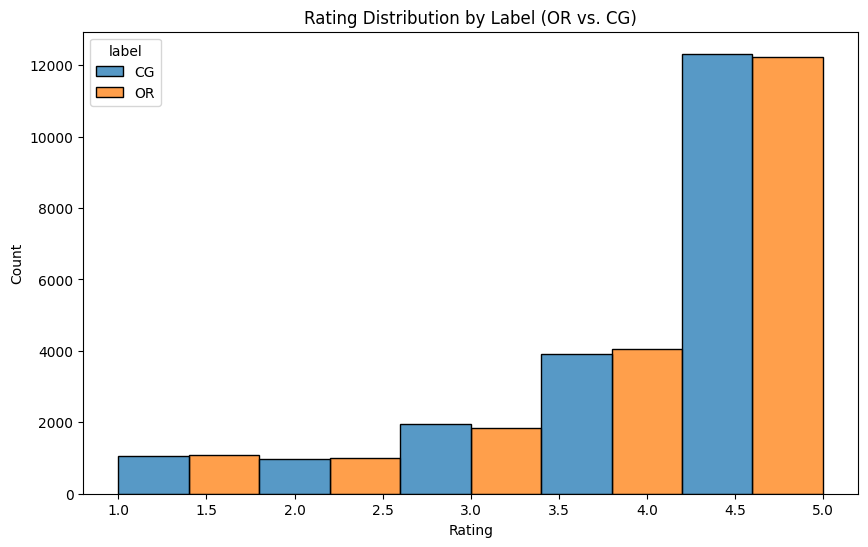

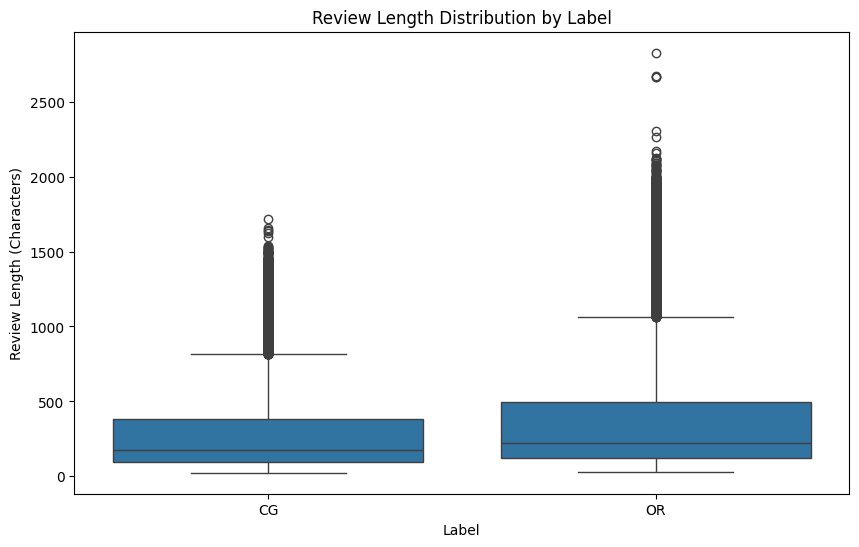

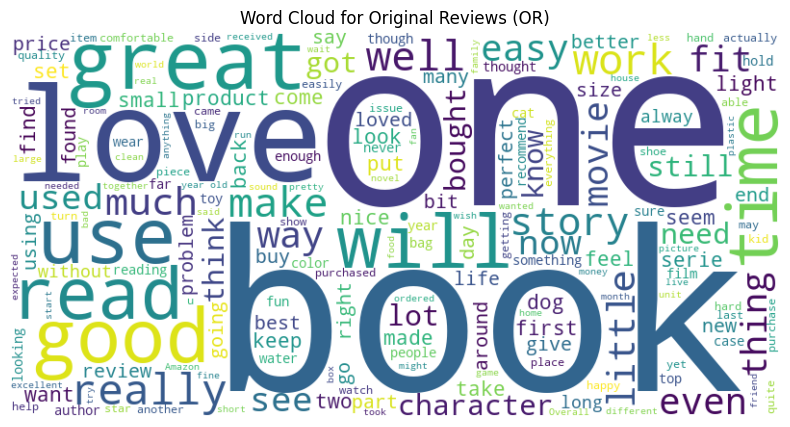

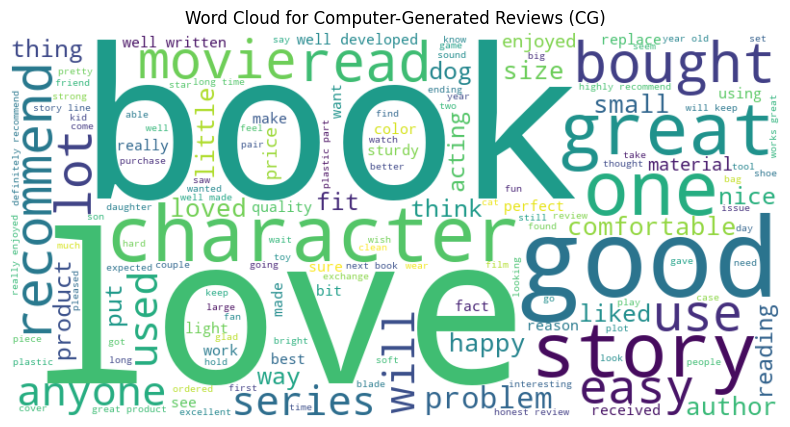

Top 10 Bigrams for OR Reviews:
of the: 6381
in the: 4942
is a: 3717
it is: 3409
i have: 3383
this is: 3145
and the: 3082
on the: 2973
and i: 2605
to the: 2561

Top 10 Bigrams for CG Reviews:
is a: 11100
and the: 8857
it is: 7677
i have: 7348
of the: 6672
and it: 5886
this book: 5263
in the: 4832
the story: 4746
i would: 4744

POS Tag Distribution (OR):
{'PRON': 0.10846038734303498, 'ADV': 0.05508685939838209, 'VERB': 0.11383894684334946, 'DET': 0.08612201522479343, 'NOUN': 0.16302674098332212, 'PUNCT': 0.10629161335097269, 'PROPN': 0.0285410657355397, 'AUX': 0.06063892081806155, 'ADJ': 0.07477932724630766, 'PART': 0.028953132794031534, 'CCONJ': 0.03424494133466351, 'ADP': 0.08184953046043072, 'SCONJ': 0.01895508469062439, 'NUM': 0.013533149710468671, 'SPACE': 0.020494914224988614, 'INTJ': 0.0016048927541260924, 'SYM': 0.0023856513912685158, 'X': 0.0011928256956342579}

POS Tag Distribution (CG):
{'NOUN': 0.14406917049446097, 'AUX': 0.08651715752499324, 'ADP': 0.06011888678735477, 'PRON

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk import ngrams
from nltk.tokenize import word_tokenize, sent_tokenize
from textstat import flesch_kincaid_grade
import spacy
from collections import Counter

nltk.download('punkt')
df = pd.read_csv('fake reviews dataset.csv')
nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])

# --- Missing Value Check ---
print("Missing Values Summary:")
print(df.isnull().sum())
print("\n")

# --- Feature Engineering ---
df['review_length'] = df['text_'].apply(len)
df['word_count'] = df['text_'].apply(lambda x: len(word_tokenize(x)))
df['sentiment_polarity'] = df['text_'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['readability'] = df['text_'].apply(flesch_kincaid_grade)

def syntactic_complexity(text):
    sentences = sent_tokenize(text)
    if not sentences:
        return 0
    return np.mean([len(word_tokenize(sent)) for sent in sentences])

df['syntactic_complexity'] = df['text_'].apply(syntactic_complexity)

# --- Summary Stats ---
print("Summary Statistics for Numeric Features:")
print(df[['review_length', 'word_count', 'sentiment_polarity', 'readability', 'syntactic_complexity']].describe())
print("\n")

# --- Visualizations ---
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='rating', hue='label', multiple='dodge', bins=5)
plt.title('Rating Distribution by Label (OR vs. CG)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='review_length', data=df)
plt.title('Review Length Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Review Length (Characters)')
plt.show()

# --- Word Clouds ---
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

or_text = ' '.join(df[df['label'] == 'OR']['text_'])
cg_text = ' '.join(df[df['label'] == 'CG']['text_'])
generate_wordcloud(or_text, 'Word Cloud for Original Reviews (OR)')
generate_wordcloud(cg_text, 'Word Cloud for Computer-Generated Reviews (CG)')

# --- N-Gram (Bigram) Analysis ---
def get_ngrams(text, n=2, top_k=10):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum()]
    return Counter(ngrams(tokens, n)).most_common(top_k)

print("Top 10 Bigrams for OR Reviews:")
for bigram, count in get_ngrams(or_text, 2, 10):
    print(f"{' '.join(bigram)}: {count}")
print("\nTop 10 Bigrams for CG Reviews:")
for bigram, count in get_ngrams(cg_text, 2, 10):
    print(f"{' '.join(bigram)}: {count}")

# --- POS Tag Distribution ---
def pos_tag_distribution(text):
    doc = nlp(text)
    pos_counts = Counter(token.pos_ for token in doc)
    total = sum(pos_counts.values())
    return {pos: count / total for pos, count in pos_counts.items()}

subset = df.sample(1000, random_state=42)
print("\nPOS Tag Distribution (OR):")
print(pos_tag_distribution(' '.join(subset[subset['label'] == 'OR']['text_'])))
print("\nPOS Tag Distribution (CG):")
print(pos_tag_distribution(' '.join(subset[subset['label'] == 'CG']['text_'])))


# Preprocess

In [4]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import emoji
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Spell correction function using TextBlob
def correct_spelling(word):
    try:
        corrected = str(TextBlob(word).correct())
        return corrected
    except:
        return word

# Function to preprocess a single review
def preprocess_text(text):
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [correct_spelling(word) for word in tokens]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

print("Preprocessing text data...")
df['text_clean'] = [preprocess_text(text) for text in tqdm(df['text_'], desc="Text Preprocessing")]

# Check for missing
print("\nMissing Values in Cleaned Text:")
print(df['text_clean'].isnull().sum())

# Split dataset
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Show split info
print("\nDataset Split Sizes:")
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

print("\nLabel Distribution in Training Set:")
print(train_df['label'].value_counts(normalize=True))
print("\nLabel Distribution in Validation Set:")
print(val_df['label'].value_counts(normalize=True))
print("\nLabel Distribution in Test Set:")
print(test_df['label'].value_counts(normalize=True))

# Save to files
train_df.to_csv('train_preprocessed.csv', index=False)
val_df.to_csv('val_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)
print("\n✅ Preprocessed datasets saved.")


Preprocessing text data...


Text Preprocessing: 100%|███████████████| 40432/40432 [2:58:04<00:00,  3.78it/s]



Missing Values in Cleaned Text:
0

Dataset Split Sizes:
Training set: 28302
Validation set: 6065
Test set: 6065

Label Distribution in Training Set:
label
OR    0.5
CG    0.5
Name: proportion, dtype: float64

Label Distribution in Validation Set:
label
OR    0.500082
CG    0.499918
Name: proportion, dtype: float64

Label Distribution in Test Set:
label
CG    0.500082
OR    0.499918
Name: proportion, dtype: float64

✅ Preprocessed datasets saved.


# Feature Engineering

In [13]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from textblob import TextBlob
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

nltk.download('punkt')
nltk.download('stopwords')

df['text_clean'] = df['text_clean'].fillna('')

# 1. TF-IDF Features
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_tfidf = tfidf_vectorizer.fit_transform(df['text_clean'])

# 2. Sentiment Scores
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

sentiment_scores = df['text_clean'].apply(get_sentiment)
df['polarity'], df['subjectivity'] = zip(*sentiment_scores)

# 3. Lexical Diversity
def lexical_diversity(text):
    tokens = word_tokenize(text)
    return len(set(tokens)) / len(tokens) if tokens else 0

df['lexical_diversity'] = df['text_clean'].apply(lexical_diversity)

# 4. Stylometric Features
def stylometric_features(text):
    sentences = nltk.sent_tokenize(text)
    tokens = word_tokenize(text)
    avg_sentence_len = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0
    punctuation_count = len(re.findall(r'[^\w\s]', text))
    function_words = set(stopwords.words('english'))
    function_word_freq = sum(1 for word in tokens if word in function_words) / len(tokens) if tokens else 0
    return avg_sentence_len, punctuation_count, function_word_freq

stylometric = df['text_clean'].apply(stylometric_features)
df['avg_sent_len'], df['punct_count'], df['func_word_freq'] = zip(*stylometric)

# 5. Combine Features
X_handcrafted = df[[
    'polarity', 'subjectivity', 'lexical_diversity',
    'avg_sent_len', 'punct_count', 'func_word_freq'
]]
X_combined = hstack([X_tfidf, csr_matrix(X_handcrafted.values)])

# 6. Prepare target
y = df['label'].factorize()[0]

# Optional: print shapes
print("TF-IDF shape:", X_tfidf.shape)
print("Handcrafted shape:", X_handcrafted.shape)
print("Combined feature shape:", X_combined.shape)


[nltk_data] Downloading package punkt to /Users/dhrubieee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dhrubieee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


TF-IDF shape: (28302, 10000)
Handcrafted shape: (28302, 6)
Combined feature shape: (28302, 10006)
